In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

In [2]:
df = pd.read_csv('BehaviourSearch_step7_GA_Pooled_Tsize60_2.5k_THRESHOLDED-Obj.modelRunHistory.csv')

In [3]:
df

,search-number,evaluation,evals-requested-so-far,number_of_agents*,number_of_opinion_dimensions*,model*,boundary_mean*,set-seed?*,avoid_seed_control?*,boundary_distribution*,...,silence_tau*,silence_delta0*,classify_proponents_by_boundary?*,use_silence?*,random-seed,min-result,max-result,mean-result,stdev-result,final-step-result
0,1,1,180,1000,1,"""HK""",0.21,False,True,"""normal""",...,8,0.4,False,True,"""-1964018020""",0.747563,0.747563,0.747563,0,0.747563
1,1,2,180,1000,1,"""HK""",0.21,False,True,"""normal""",...,8,0.4,False,True,"""-493362244""",0.752459,0.752459,0.752459,0,0.752459
2,1,3,180,1000,1,"""HK""",0.21,False,True,"""normal""",...,8,0.4,False,True,"""-1507264241""",0.751752,0.751752,0.751752,0,0.751752
3,1,4,180,1000,1,"""HK""",0.14,False,True,"""normal""",...,7,-0.2,True,True,"""-2015344209""",0.917387,0.917387,0.917387,0,0.917387
4,1,5,180,1000,1,"""HK""",0.14,False,True,"""normal""",...,7,-0.2,True,True,"""-1221871312""",0.904306,0.904306,0.904306,0,0.904306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996,1,1997,2013,1000,1,"""HK""",0.01,False,True,"""normal""",...,6,0.7,True,True,"""-228805226""",263.999965,263.999965,263.999965,0,263.999965
1997,1,1998,2013,1000,1,"""HK""",0.01,False,True,"""normal""",...,6,0.7,True,True,"""804947882""",307.999301,307.999301,307.999301,0,307.999301
1998,1,1999,2016,1000,1,"""HK""",0.05,False,True,"""normal""",...,6,0.9,False,False,"""-180063332""",153.999956,153.999956,153.999956,0,153.999956
1999,1,2000,2016,1000,1,"""HK""",0.05,False,True,"""normal""",...,6,0.9,False,False,"""-903762568""",134.999860,134.999860,134.999860,0,134.999860


Starting quick consistency analysis...
TRIPLET CONSISTENCY ANALYSIS

1. TRIPLET STATISTICS
--------------------------------------------------------------------------------
Total number of triplets: 667
Total evaluations: 2001

Triplet Statistics Summary:
  Mean within-triplet std: 15.936263
  Max within-triplet std: 114.685266
  Min within-triplet std: 0.000000
  Mean range: 37.128691
  Mean CV (%): 17.92%

2. CONSISTENCY METRICS
--------------------------------------------------------------------------------
Within-triplet variance (mean of variances): 253.96446996
Between-triplet variance (variance of means): 11613.04911569
Total variance: 12155.49993598

Within-triplet variance / Total variance: 0.021
  (Lower = more consistent; < 0.3 indicates good consistency)
Between-triplet variance / Total variance: 0.955

Intraclass Correlation Coefficient (ICC): 0.979
  (ICC > 0.75 = excellent consistency; 0.4-0.75 = fair; < 0.4 = poor)

3. PARAMETER-WISE CONSISTENCY
-------------------------

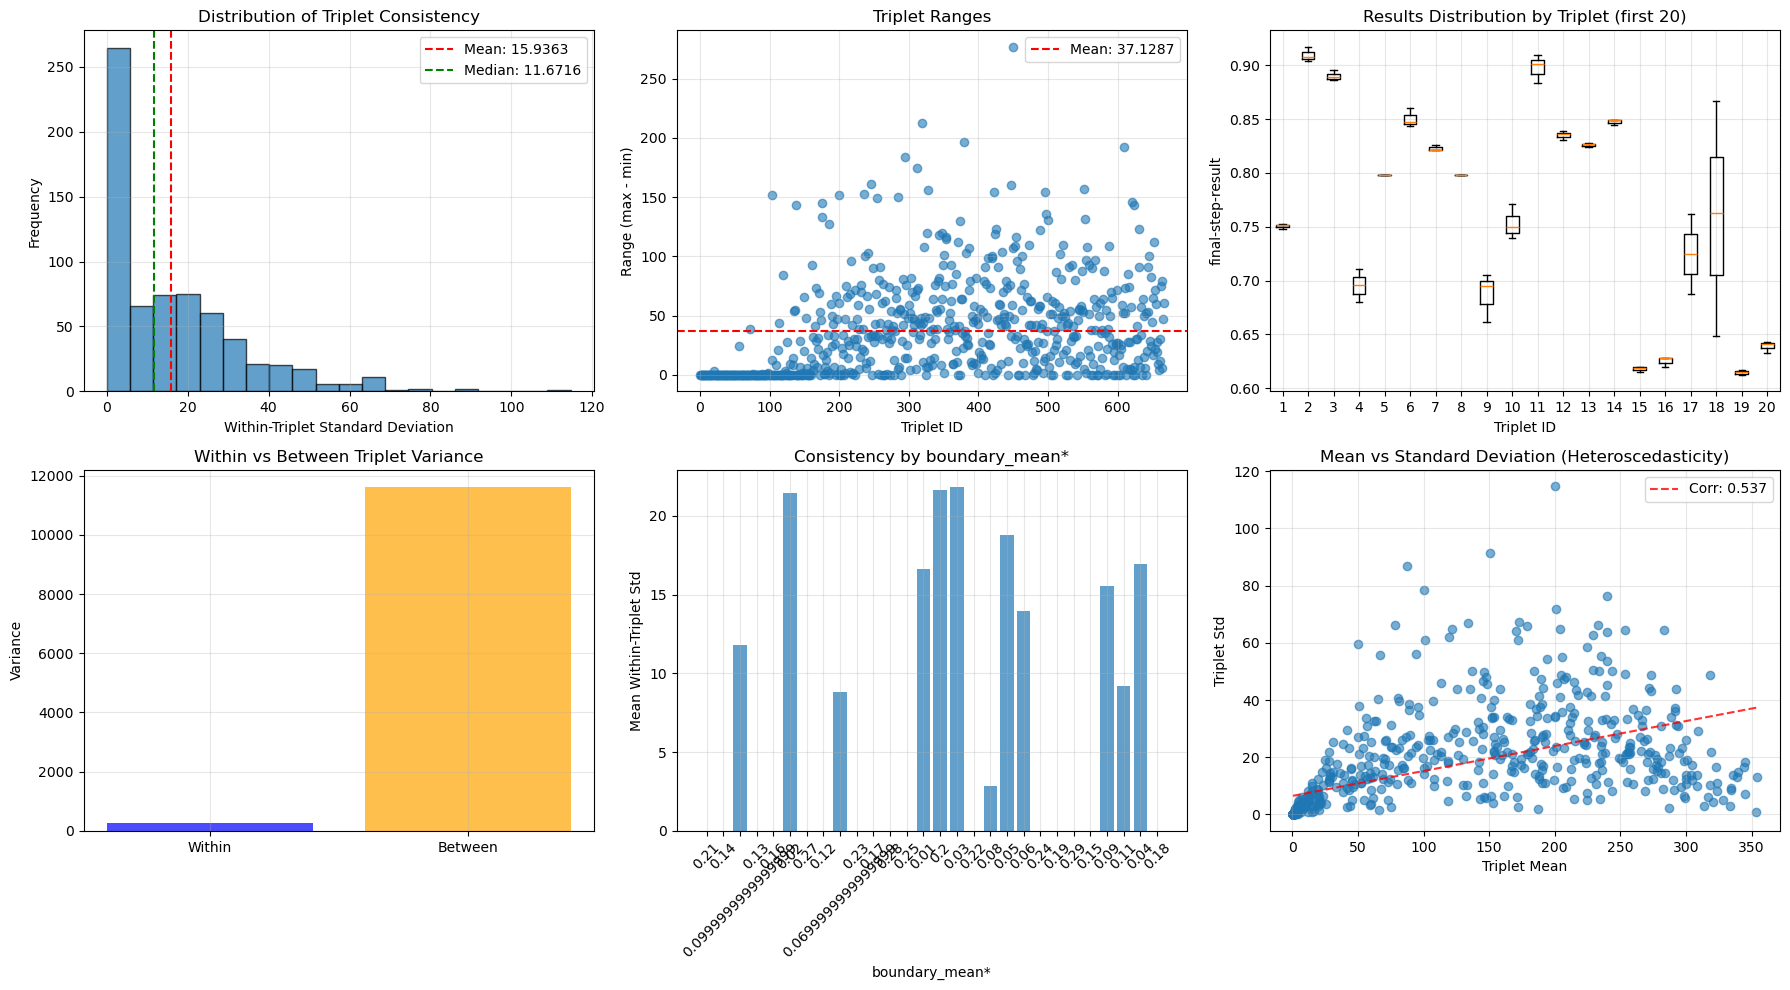


6. SUMMARY REPORT

OVERALL CONSISTENCY RATING: EXCELLENT
  ICC: 0.979
  Mean within-triplet std: 15.936263

MOST CONSISTENT TRIPLET (Triplet 4):
  Std: 0.000000
  Range: 0.000000
  Params: {'model*': '"HK"', 'boundary_mean*': 0.16, 'boundary_distribution*': '"normal"', 'silence_tau*': 5, 'silence_delta0*': 0.5, 'use_silence?*': False}

LEAST CONSISTENT TRIPLET (Triplet 450):
  Std: 114.685266
  Range: 277.000463
  Params: {'model*': '"HK"', 'boundary_mean*': 0.02, 'boundary_distribution*': '"normal"', 'silence_tau*': 0, 'silence_delta0*': 0.3, 'use_silence?*': False}

✓ Triplet statistics saved to 'triplet_consistency_stats.csv'
✓ Detailed results with triplet labels saved to 'analysis_with_triplets.csv'

RANDOMIZATION TEST
Observed ICC: 0.9326
Mean random ICC: 0.2503
95% CI of random ICC: [0.2267, 0.2769]
P-value (observed >= random): 0.0000

✓ Consistency is SIGNIFICANTLY better than random (p < 0.05)


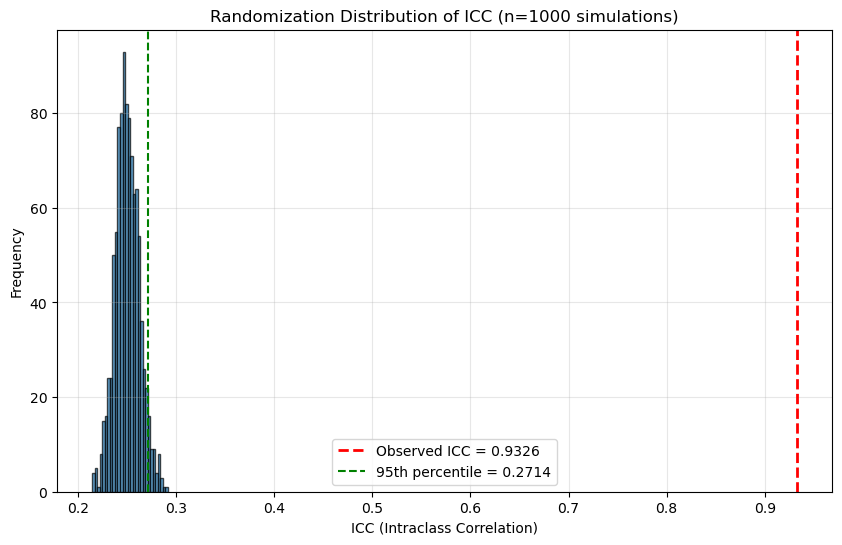


ANALYSIS COMPLETE

Key findings:
  Consistency rating: EXCELLENT
  ICC: 0.979
  P-value (vs random): 0.0000

Check the visualizations and exported CSV files for details.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error

def analyze_triplet_consistency(df):
    """
    Analyze consistency of final-step-result across triplets of evaluations.
    Each triplet represents 3 runs with the same parameters but different random seeds.
    """
    
    # Make a copy to avoid modifying original
    df = df.copy()
    
    # Group by triplet (every 3 consecutive evaluations)
    # Assuming evaluation column starts at 1 and is sequential
    df['triplet_id'] = (df['evaluation'] - 1) // 3
    
    print("="*80)
    print("TRIPLET CONSISTENCY ANALYSIS")
    print("="*80)
    
    # ========================================================================
    # 1. Basic Statistics per Triplet
    # ========================================================================
    
    print("\n1. TRIPLET STATISTICS")
    print("-"*80)
    
    triplet_stats = []
    triplet_results = {}
    
    for triplet_id in df['triplet_id'].unique():
        triplet_data = df[df['triplet_id'] == triplet_id]
        results = triplet_data['final-step-result'].values
        
        # Store for later
        triplet_results[triplet_id] = results
        
        # Calculate statistics
        mean_val = np.mean(results)
        std_val = np.std(results)
        min_val = np.min(results)
        max_val = np.max(results)
        range_val = max_val - min_val
        cv_val = (std_val / mean_val) * 100 if mean_val != 0 else np.nan  # Coefficient of variation
        
        # Get the parameters (they should be the same within triplet)
        params = triplet_data.iloc[0][['model*', 'boundary_mean*', 'boundary_distribution*', 
                                      'silence_tau*', 'silence_delta0*', 'use_silence?*']].to_dict()
        
        triplet_stats.append({
            'triplet_id': triplet_id,
            'eval_indices': triplet_data['evaluation'].tolist(),
            'mean': mean_val,
            'std': std_val,
            'min': min_val,
            'max': max_val,
            'range': range_val,
            'cv': cv_val,
            'results': results,
            'params': params
        })
    
    triplet_df = pd.DataFrame(triplet_stats)
    
    # Print summary
    print(f"Total number of triplets: {len(triplet_stats)}")
    print(f"Total evaluations: {len(df)}")
    print(f"\nTriplet Statistics Summary:")
    print(f"  Mean within-triplet std: {triplet_df['std'].mean():.6f}")
    print(f"  Max within-triplet std: {triplet_df['std'].max():.6f}")
    print(f"  Min within-triplet std: {triplet_df['std'].min():.6f}")
    print(f"  Mean range: {triplet_df['range'].mean():.6f}")
    print(f"  Mean CV (%): {triplet_df['cv'].mean():.2f}%")
    
    # ========================================================================
    # 2. Consistency Metrics
    # ========================================================================
    
    print("\n2. CONSISTENCY METRICS")
    print("-"*80)
    
    # Calculate various consistency measures
    all_results = df['final-step-result'].values
    
    # Within-triplet vs between-triplet variance
    within_var = triplet_df['std'].mean()**2
    between_var = triplet_df['mean'].var()
    total_var = np.var(all_results)
    
    print(f"Within-triplet variance (mean of variances): {within_var:.8f}")
    print(f"Between-triplet variance (variance of means): {between_var:.8f}")
    print(f"Total variance: {total_var:.8f}")
    
    # Ratio of within to total variance (lower = more consistent)
    within_ratio = within_var / total_var if total_var > 0 else np.nan
    print(f"\nWithin-triplet variance / Total variance: {within_ratio:.3f}")
    print(f"  (Lower = more consistent; < 0.3 indicates good consistency)")
    
    # Percentage of variance explained by between-triplet differences
    between_ratio = between_var / total_var if total_var > 0 else np.nan
    print(f"Between-triplet variance / Total variance: {between_ratio:.3f}")
    
    # Intraclass Correlation Coefficient (ICC) approximation
    # ICC = between_var / (between_var + within_var)
    icc = between_var / (between_var + within_var) if (between_var + within_var) > 0 else np.nan
    print(f"\nIntraclass Correlation Coefficient (ICC): {icc:.3f}")
    print(f"  (ICC > 0.75 = excellent consistency; 0.4-0.75 = fair; < 0.4 = poor)")
    
    # ========================================================================
    # 3. Parameter-wise Consistency Analysis
    # ========================================================================
    
    print("\n3. PARAMETER-WISE CONSISTENCY")
    print("-"*80)
    
    # Group by parameter combinations to see if some are more consistent
    param_cols = ['model*', 'boundary_mean*', 'boundary_distribution*', 
                  'silence_tau*', 'silence_delta0*', 'use_silence?*']
    
    # Add triplet-level statistics to main df
    for triplet_id in triplet_df['triplet_id']:
        mask = df['triplet_id'] == triplet_id
        triplet_mean = triplet_df[triplet_df['triplet_id'] == triplet_id]['mean'].values[0]
        triplet_std = triplet_df[triplet_df['triplet_id'] == triplet_id]['std'].values[0]
        triplet_range = triplet_df[triplet_df['triplet_id'] == triplet_id]['range'].values[0]
        
        df.loc[mask, 'triplet_mean'] = triplet_mean
        df.loc[mask, 'triplet_std'] = triplet_std
        df.loc[mask, 'triplet_range'] = triplet_range
    
    # Analyze by parameter groups
    for param in param_cols:
        print(f"\n  Consistency by {param}:")
        
        # Get unique values for this parameter
        unique_vals = df[param].unique()
        
        for val in unique_vals:
            if pd.isna(val):
                continue
            # Get triplets with this parameter value
            triplet_ids = df[df[param] == val]['triplet_id'].unique()
            subset_df = triplet_df[triplet_df['triplet_id'].isin(triplet_ids)]
            
            if len(subset_df) > 0:
                mean_std = subset_df['std'].mean()
                mean_range = subset_df['range'].mean()
                n_triplets = len(subset_df)
                
                print(f"    {param}={val}: n={n_triplets}, mean_std={mean_std:.6f}, mean_range={mean_range:.6f}")
    
    # ========================================================================
    # 4. Outlier Detection
    # ========================================================================
    
    print("\n4. OUTLIER TRIPLETS (High Inconsistency)")
    print("-"*80)
    
    # Identify triplets with high within-triplet variance
    std_threshold = triplet_df['std'].mean() + 2 * triplet_df['std'].std()
    outlier_triplets = triplet_df[triplet_df['std'] > std_threshold]
    
    if len(outlier_triplets) > 0:
        print(f"Triplets with std > {std_threshold:.6f}:")
        for _, row in outlier_triplets.iterrows():
            print(f"\n  Triplet {row['triplet_id']}:")
            print(f"    Eval indices: {row['eval_indices']}")
            print(f"    Results: {row['results']}")
            print(f"    Std: {row['std']:.6f}")
            print(f"    Range: {row['range']:.6f}")
            print(f"    Params: {row['params']}")
    else:
        print("No outlier triplets detected (all within 2 std of mean)")
    
    # ========================================================================
    # 5. Visualizations
    # ========================================================================
    
    print("\n5. GENERATING VISUALIZATIONS...")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Plot 1: Distribution of triplets' standard deviations
    ax1 = axes[0, 0]
    ax1.hist(triplet_df['std'], bins=20, edgecolor='black', alpha=0.7)
    ax1.axvline(triplet_df['std'].mean(), color='red', linestyle='--', label=f'Mean: {triplet_df["std"].mean():.4f}')
    ax1.axvline(np.median(triplet_df['std']), color='green', linestyle='--', label=f'Median: {np.median(triplet_df["std"]):.4f}')
    ax1.set_xlabel('Within-Triplet Standard Deviation')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Triplet Consistency')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot 2: Triplet ranges (min-max distance)
    ax2 = axes[0, 1]
    ax2.scatter(range(len(triplet_df)), triplet_df['range'], alpha=0.6)
    ax2.axhline(triplet_df['range'].mean(), color='red', linestyle='--', label=f'Mean: {triplet_df["range"].mean():.4f}')
    ax2.set_xlabel('Triplet ID')
    ax2.set_ylabel('Range (max - min)')
    ax2.set_title('Triplet Ranges')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Plot 3: Boxplot of results by triplet
    ax3 = axes[0, 2]
    # Show only first 20 triplets for readability
    n_show = min(20, len(triplet_stats))
    data_to_plot = [stats['results'] for stats in triplet_stats[:n_show]]
    ax3.boxplot(data_to_plot)
    ax3.set_xlabel('Triplet ID')
    ax3.set_ylabel('final-step-result')
    ax3.set_title(f'Results Distribution by Triplet (first {n_show})')
    ax3.grid(alpha=0.3)
    
    # Plot 4: Within vs Between variance
    ax4 = axes[1, 0]
    variance_data = ['Within', 'Between']
    variance_values = [within_var, between_var]
    ax4.bar(variance_data, variance_values, color=['blue', 'orange'], alpha=0.7)
    ax4.set_ylabel('Variance')
    ax4.set_title('Within vs Between Triplet Variance')
    ax4.grid(alpha=0.3)
    
    # Plot 5: Parameter effect on consistency (using boundary_mean as example)
    ax5 = axes[1, 1]
    param_name = 'boundary_mean*'
    param_values = df[param_name].unique()
    param_consistency = []
    for val in param_values:
        if pd.isna(val):
            continue
        triplet_ids = df[df[param_name] == val]['triplet_id'].unique()
        subset_df = triplet_df[triplet_df['triplet_id'].isin(triplet_ids)]
        param_consistency.append({
            'param_value': val,
            'mean_std': subset_df['std'].mean(),
            'n': len(subset_df)
        })
    
    if param_consistency:
        param_consistency_df = pd.DataFrame(param_consistency)
        ax5.bar([str(p['param_value']) for p in param_consistency], 
                [p['mean_std'] for p in param_consistency],
                alpha=0.7)
        ax5.set_xlabel(param_name)
        ax5.set_ylabel('Mean Within-Triplet Std')
        ax5.set_title(f'Consistency by {param_name}')
        ax5.grid(alpha=0.3)
        ax5.tick_params(axis='x', rotation=45)
    
    # Plot 6: Relationship between mean and std (heteroscedasticity check)
    ax6 = axes[1, 2]
    ax6.scatter(triplet_df['mean'], triplet_df['std'], alpha=0.6)
    ax6.set_xlabel('Triplet Mean')
    ax6.set_ylabel('Triplet Std')
    ax6.set_title('Mean vs Standard Deviation (Heteroscedasticity)')
    ax6.grid(alpha=0.3)
    
    # Add correlation line
    if len(triplet_df) > 1:
        z = np.polyfit(triplet_df['mean'], triplet_df['std'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(triplet_df['mean'].min(), triplet_df['mean'].max(), 100)
        ax6.plot(x_range, p(x_range), 'r--', alpha=0.8, 
                label=f'Corr: {triplet_df["mean"].corr(triplet_df["std"]):.3f}')
        ax6.legend()
    
    plt.tight_layout()
    plt.show()
    
    # ========================================================================
    # 6. Summary Report
    # ========================================================================
    
    print("\n6. SUMMARY REPORT")
    print("="*80)
    
    # Overall consistency rating
    if icc > 0.75:
        consistency_rating = "EXCELLENT"
    elif icc > 0.60:
        consistency_rating = "GOOD"
    elif icc > 0.40:
        consistency_rating = "FAIR"
    else:
        consistency_rating = "POOR"
    
    print(f"\nOVERALL CONSISTENCY RATING: {consistency_rating}")
    print(f"  ICC: {icc:.3f}")
    print(f"  Mean within-triplet std: {triplet_df['std'].mean():.6f}")
    
    # Best and worst triplets
    best_triplet = triplet_df.loc[triplet_df['std'].idxmin()]
    worst_triplet = triplet_df.loc[triplet_df['std'].idxmax()]
    
    print(f"\nMOST CONSISTENT TRIPLET (Triplet {best_triplet['triplet_id']}):")
    print(f"  Std: {best_triplet['std']:.6f}")
    print(f"  Range: {best_triplet['range']:.6f}")
    print(f"  Params: {best_triplet['params']}")
    
    print(f"\nLEAST CONSISTENT TRIPLET (Triplet {worst_triplet['triplet_id']}):")
    print(f"  Std: {worst_triplet['std']:.6f}")
    print(f"  Range: {worst_triplet['range']:.6f}")
    print(f"  Params: {worst_triplet['params']}")
    
    # ========================================================================
    # 7. Export Results
    # ========================================================================
    
    # Export triplet statistics
    triplet_df.to_csv('triplet_consistency_stats.csv', index=False)
    print(f"\n✓ Triplet statistics saved to 'triplet_consistency_stats.csv'")
    
    # Export detailed results with triplet labels
    df.to_csv('analysis_with_triplets.csv', index=False)
    print(f"✓ Detailed results with triplet labels saved to 'analysis_with_triplets.csv'")
    
    return {
        'triplet_stats': triplet_df,
        'df_with_triplets': df,
        'within_var': within_var,
        'between_var': between_var,
        'total_var': total_var,
        'icc': icc,
        'consistency_rating': consistency_rating,
        'outlier_triplets': outlier_triplets
    }


# ============================================================================
# Additional Analysis: Compare actual vs expected consistency
# ============================================================================

def test_random_expectation(df, n_simulations=1000):
    """
    Test if the observed consistency is better than random expectation.
    Randomly shuffle results across triplets and compute expected ICC.
    """
    print("\n" + "="*80)
    print("RANDOMIZATION TEST")
    print("="*80)
    
    # Get triplet structure
    df_copy = df.copy()
    df_copy['triplet_id'] = (df_copy['evaluation'] - 1) // 3
    
    # Observed ICC
    triplet_stats = df_copy.groupby('triplet_id')['final-step-result'].agg(['mean', 'std'])
    within_var = (triplet_stats['std'] ** 2).mean()
    between_var = triplet_stats['mean'].var()
    observed_icc = between_var / (between_var + within_var) if (between_var + within_var) > 0 else np.nan
    
    # Randomization
    random_iccs = []
    all_results = df_copy['final-step-result'].values
    
    for i in range(n_simulations):
        # Shuffle results
        shuffled = np.random.permutation(all_results)
        df_shuffled = df_copy.copy()
        df_shuffled['final-step-result'] = shuffled
        
        # Calculate ICC on shuffled data
        triplet_stats_shuffled = df_shuffled.groupby('triplet_id')['final-step-result'].agg(['mean', 'std'])
        within_var_shuffled = (triplet_stats_shuffled['std'] ** 2).mean()
        between_var_shuffled = triplet_stats_shuffled['mean'].var()
        
        if (between_var_shuffled + within_var_shuffled) > 0:
            icc_shuffled = between_var_shuffled / (between_var_shuffled + within_var_shuffled)
        else:
            icc_shuffled = np.nan
        
        random_iccs.append(icc_shuffled)
    
    random_iccs = np.array(random_iccs)
    random_iccs = random_iccs[~np.isnan(random_iccs)]
    
    # Calculate p-value
    p_value = np.mean(random_iccs >= observed_icc) if observed_icc is not np.nan else np.nan
    
    print(f"Observed ICC: {observed_icc:.4f}")
    print(f"Mean random ICC: {np.mean(random_iccs):.4f}")
    print(f"95% CI of random ICC: [{np.percentile(random_iccs, 2.5):.4f}, {np.percentile(random_iccs, 97.5):.4f}]")
    print(f"P-value (observed >= random): {p_value:.4f}")
    
    if p_value < 0.05:
        print("\n✓ Consistency is SIGNIFICANTLY better than random (p < 0.05)")
    else:
        print("\n⚠️ Consistency is NOT significantly better than random (p >= 0.05)")
    
    # Visualize randomization distribution
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(random_iccs, bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(observed_icc, color='red', linestyle='--', linewidth=2, 
              label=f'Observed ICC = {observed_icc:.4f}')
    ax.axvline(np.percentile(random_iccs, 95), color='green', linestyle='--', 
              label=f'95th percentile = {np.percentile(random_iccs, 95):.4f}')
    ax.set_xlabel('ICC (Intraclass Correlation)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Randomization Distribution of ICC (n={n_simulations} simulations)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
    
    return {
        'observed_icc': observed_icc,
        'random_iccs': random_iccs,
        'p_value': p_value,
        'mean_random_icc': np.mean(random_iccs),
        'ci_lower': np.percentile(random_iccs, 2.5),
        'ci_upper': np.percentile(random_iccs, 97.5)
    }


# ============================================================================
# Quick Analysis Function
# ============================================================================

def quick_consistency_check(df):
    """
    Quick run of all analyses
    """
    print("Starting quick consistency analysis...")
    
    # Main analysis
    results = analyze_triplet_consistency(df)
    
    # Randomization test
    rand_results = test_random_expectation(df)
    
    return results, rand_results


# ============================================================================
# Example Usage
# ============================================================================

# Run the analysis
if __name__ == "__main__":
    # Assuming your dataframe is named 'df'
    try:
        # Full analysis
        results, rand_results = quick_consistency_check(df)
        
        print("\n" + "="*80)
        print("ANALYSIS COMPLETE")
        print("="*80)
        print("\nKey findings:")
        print(f"  Consistency rating: {results['consistency_rating']}")
        print(f"  ICC: {results['icc']:.3f}")
        print(f"  P-value (vs random): {rand_results['p_value']:.4f}")
        print("\nCheck the visualizations and exported CSV files for details.")
        
    except NameError:
        print("Error: 'df' not found. Please load your dataframe first.")
        print("Example: df = pd.read_csv('your_data.csv')")
    except Exception as e:
        print(f"Error during analysis: {str(e)}")
        import traceback
        traceback.print_exc()